In [37]:
import pandas as pd
import seaborn as sns
df=sns.load_dataset('tips')
print(df.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [38]:
df['tip_category'] = df['tip'].apply(lambda x: 1 if x > df['tip'].median() else 0)

In [39]:
df

,total_bill,tip,sex,smoker,day,time,size,tip_category
0,16.99,1.01,Female,No,Sun,Dinner,2,0
1,10.34,1.66,Male,No,Sun,Dinner,3,0
2,21.01,3.50,Male,No,Sun,Dinner,3,1
3,23.68,3.31,Male,No,Sun,Dinner,2,1
4,24.59,3.61,Female,No,Sun,Dinner,4,1
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,1
240,27.18,2.00,Female,Yes,Sat,Dinner,2,0
241,22.67,2.00,Male,Yes,Sat,Dinner,2,0
242,17.82,1.75,Male,No,Sat,Dinner,2,0


In [40]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [41]:
df_encoded

,total_bill,tip,size,tip_category,sex_Female,smoker_No,day_Fri,day_Sat,day_Sun,time_Dinner
0,16.99,1.01,2,0,True,True,False,False,True,True
1,10.34,1.66,3,0,False,True,False,False,True,True
2,21.01,3.50,3,1,False,True,False,False,True,True
3,23.68,3.31,2,1,False,True,False,False,True,True
4,24.59,3.61,4,1,True,True,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,3,1,False,True,False,True,False,True
240,27.18,2.00,2,0,True,False,False,True,False,True
241,22.67,2.00,2,0,False,False,False,True,False,True
242,17.82,1.75,2,0,False,True,False,True,False,True


In [42]:
X = df_encoded.drop(['tip', 'tip_category'], axis=1)
y = df_encoded['tip_category']

In [43]:
X

,total_bill,size,sex_Female,smoker_No,day_Fri,day_Sat,day_Sun,time_Dinner
0,16.99,2,True,True,False,False,True,True
1,10.34,3,False,True,False,False,True,True
2,21.01,3,False,True,False,False,True,True
3,23.68,2,False,True,False,False,True,True
4,24.59,4,True,True,False,False,True,True
...,...,...,...,...,...,...,...,...
239,29.03,3,False,True,False,True,False,True
240,27.18,2,True,False,False,True,False,True
241,22.67,2,False,False,False,True,False,True
242,17.82,2,False,True,False,True,False,True


In [44]:
y

0      0
1      0
2      1
3      1
4      1
      ..
239    1
240    0
241    0
242    0
243    1
Name: tip_category, Length: 244, dtype: int64

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [46]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [47]:
y_pred = model.predict(X_test)

In [48]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6756756756756757
              precision    recall  f1-score   support

           0       0.70      0.77      0.73        43
           1       0.63      0.55      0.59        31

    accuracy                           0.68        74
   macro avg       0.67      0.66      0.66        74
weighted avg       0.67      0.68      0.67        74



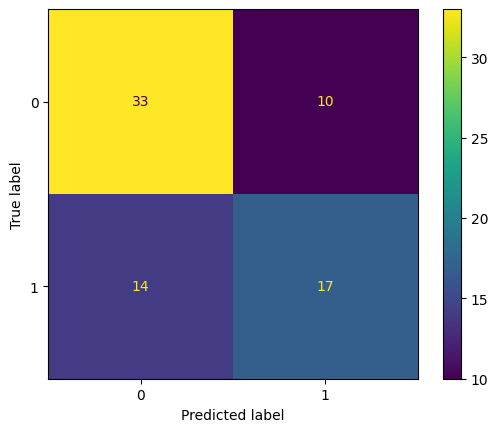

In [49]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

In [50]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Convert to integers (important for MultinomialNB)
X_scaled = (X_scaled * 10).astype(int)

In [51]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

In [53]:
y_pred = model.predict(X_test)

C:\Users\Kirat\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(


In [54]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5675675675675675
              precision    recall  f1-score   support

           0       0.58      0.98      0.72        43
           1       0.00      0.00      0.00        31

    accuracy                           0.57        74
   macro avg       0.29      0.49      0.36        74
weighted avg       0.33      0.57      0.42        74



In [55]:
from sklearn.preprocessing import Binarizer

binarizer = Binarizer(threshold=X.mean().mean())
X_bin = binarizer.fit_transform(X)

In [56]:
from sklearn.naive_bayes import BernoulliNB

model = BernoulliNB()
model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,binarize,0.0
,fit_prior,True
,class_prior,None


In [57]:
y_pred = model.predict(X_test)

In [58]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5675675675675675
              precision    recall  f1-score   support

           0       0.68      0.49      0.57        43
           1       0.49      0.68      0.57        31

    accuracy                           0.57        74
   macro avg       0.58      0.58      0.57        74
weighted avg       0.60      0.57      0.57        74

